# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA INFERENCIAL**

Una vez visto la presentación ***Introducción a la estadística inferencial***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1wBQxgzbO4PV0meYNF_UCzhk7p6yC_xGu?usp=sharing).


## **PRUEBA DE HIPÓTESIS**

La **prueba de hipótesis** es un procedimiento formal dentro de la estadística inferencial que se usa para aceptar o rechazar una afirmación sobre un parámetro poblacional. Se basa en comparar dos hipótesis opuestas: la nula ($H_0$) y la alternativa ($H_1$).

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas**, **Seaborn** y **Scipy** para usar datasets precargados y operaciones estadísticas sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [1]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Importar dataset
df_tips = sns.load_dataset('tips')
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### **NIVEL DE SIGNIFICANCIA:**

Es el umbral de error que estamos dispuestos a aceptar. Comúnmente se utiliza **$\alpha = 0.01, 0.05, 0.1$** representando el 1%, 5%, y 10% de nivel de significancia correspondientemente.

* Si el **p-value < $\alpha$**: Rechazamos $H_0$ (Hay evidencia estadística).

* Si el **p-value > $\alpha$**: No podemos rechazar $H_0$ (No hay suficiente evidencia).

In [3]:
# Importar módulo
from scipy import stats

**Caso práctico:** ¿Existe una diferencia significativa entre la propina que dan los fumadores vs. los no fumadores?

* $H_0$: La media de propinas es igual para ambos grupos.

* $H_1$: La media de propinas es distinta entre fumadores y no fumadores.

In [4]:
# Separaración de grupos
propinas_fumadores  = df_tips[df_tips['smoker'] == 'Yes']['tip']
propinas_no_fumadores = df_tips[df_tips['smoker'] == 'No']['tip']

In [5]:
# Aplicar Prueba T de Student
t_stat, p_value = stats.ttest_ind(propinas_fumadores, propinas_no_fumadores)    
print(f'Estadístico t: {t_stat:.4f}')
print(f'Valor p: {p_value:.4f}')

Estadístico t: 0.0922
Valor p: 0.9266


In [6]:
# Interpretar resultados

if p_value < 0.01:
    print('Conclusiòn: Rechazamos la hipótesis nula. Hay una diferencia significativa en las propinas entre fumadores y no fumadores. ')
    print('Existe una diferencia significativa en las propinas entre fumadores y no fumadores.  ')
if p_value >= 0.01 and p_value < 0.05:
    print('Conclusiòn: Rechazamos la hipótesis nula. Hay una diferencia significativa en las propinas entre fumadores y no fumadores. ')
    print('Existe una diferencia significativa en las propinas entre fumadores y no fumadores.  ')
if p_value >= 0.05 and p_value < 0.1:
    print('Conclusiòn: No rechazamos la hipótesis nula. No hay suficiente evidencia para afirmar que existe una diferencia significativa en las propinas entre fumadores y no fumadores. ')
    print('No existe una diferencia significativa en las propinas entre fumadores y no fumadores.  ')
else:
    print('Conclusiòn: No rechazamos la hipótesis nula. No hay suficiente evidencia para afirmar que existe una diferencia significativa en las propinas entre fumadores y no fumadores. ')
    print('No existe una diferencia significativa en las propinas entre fumadores y no fumadores.  ')

Conclusiòn: No rechazamos la hipótesis nula. No hay suficiente evidencia para afirmar que existe una diferencia significativa en las propinas entre fumadores y no fumadores. 
No existe una diferencia significativa en las propinas entre fumadores y no fumadores.  


## **APRENDIZAJE ESTADÍSTICO**

El **aprendizaje estadístico** es un marco de trabajo que **combina la estadística y la computación** para construir **modelos predictivos o de clasificación** a partir de los datos. Es la base teórica de lo que hoy conocemos como Machine Learning.

### **REGRESIÓN LINEAL SIMPLE:**



Una **regresión lineal simple** es un método estadístico utilizado para modelar la relación entre una variable independiente, el cual actua como una **variable predictora**, y una variable dependiente que actua como una **variable objetivo**.

Su objetivo es encontrar una línea recta que mejor se ajuste a los datos para **predecir un valor objetivo en función del valor predictor**.

Una regresión lineal tiene la forma:

\begin{equation} \overline{y} = β\overline{x} + α  \, \, \, \equiv \, \, \, y = mx + b \end{equation}

Y su función de costo:

\begin{equation} c(x) = \frac{1}{n} Σ_{i=1}^n(\overline{y} - y_i)² \end{equation}

In [7]:
# Definir regresión lineal
x = df_tips['total_bill']
y = df_tips['tip']

linea_regresion = np.polyfit(x, y, 1)
beta, alpha = linea_regresion
print(f'y = {beta:.4f}x + {alpha:.4f}')

y = 0.1050x + 0.9203


In [8]:
# Predicción de valores con regresión lineal
value_user = 50
y_pred = beta * value_user + alpha
print(f'El valor predicho de propina para una cuenta total de {value_user} es: {y_pred:.2f}')

El valor predicho de propina para una cuenta total de 50 es: 6.17


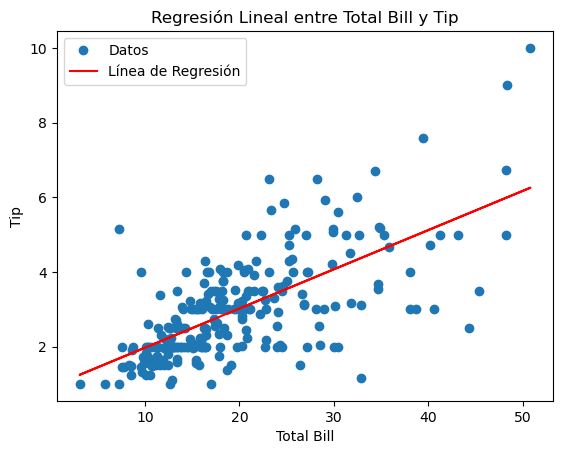

In [9]:
# Visualizar regresión lineal
plt.plot(x, y, 'o', label='Datos')
plt.plot(x, beta * x + alpha, 'r-', label='Línea de Regresión')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Regresión Lineal entre Total Bill y Tip')
plt.legend()
plt.show()

In [10]:
# Iterar pérdida de la regresión lineal
num_iterations = 100
perdida = []
for i in range(num_iterations):
    y_pred = np.polyval(linea_regresion, x)
    error = ((y - y_pred) ** 2).mean()
    perdida.append(error)

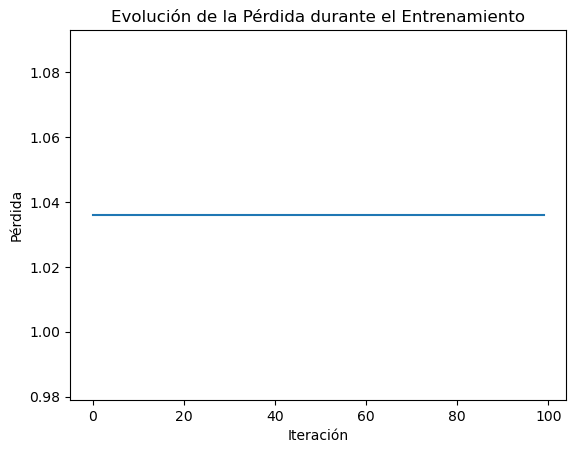

In [11]:
# Visualizar pérdida de la regresión lineal
plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.title('Evolución de la Pérdida durante el Entrenamiento')
plt.show()

### **DESCENSO DE GRADIENTE:**

El **descenso de gradiente** es un algoritmo de optimización ampliamente utilizado en el campo del aprendizaje automático y en la resolución numérica de problemas de optimización.

Su objetivo principal es encontrar el **mínimo de una función**, lo que es esencial en la optimización de modelos y la resolución de problemas matemáticos, para ajustar los parámetros de manera que la **función de costo se minimice**.

El descenso de gradiente tiene la forma:

\begin{equation} (ϴ_0, ϴ_1)_{i+1} = (ϴ_0, ϴ_1)_i - α * \frac{∂\,\,c(ϴ_0, ϴ_1)}{∂(ϴ_0, ϴ_1)} \, \, \,\, \, \,\, \, \, ; \, \, \,\, \, \,\, \, \, α \in (0, 1) \end{equation}

Donde su predicción:

\begin{equation} h_ϴ(x) = ϴ_1x + ϴ_0  \, \, \, \equiv \, \, \, y = mx + b \end{equation}


In [12]:
# Definir parámetros
tamaño_paso = 0.0001
theta_0 = 0
theta_1 = 0
perdida = []

La función de costo tiene la forma:

\begin{equation} c(ϴ_0, ϴ_1) = \frac{1}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)² \end{equation}

Al derivar función de costo:

*   Parámetro 1:

\begin{equation} \frac{∂}{∂(ϴ_0)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i) \end{equation}


*   Paramétro 2:

\begin{equation} \frac{∂}{∂(ϴ_1)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)(x_i) \end{equation}

In [13]:
# Realizar algoritmo del descenso de gradiente
num_iterations = 100
for i in range(num_iterations):
    y_pred = theta_0 + theta_1 * x
    error = ((y - y_pred) ** 2).mean()
    perdida.append(error)
    d_theta_0 = (2/len(x)) * (y_pred - y).sum()
    d_theta_1 = (2/len(x)) * ((y_pred - y) * x).sum()
    
    theta_0 -= tamaño_paso * d_theta_0
    theta_1 -= tamaño_paso * d_theta_1
print(f'Parámetros finales: theta_0 = {theta_0:.4f}, theta_1 = {theta_1:.4f}')

Parámetros finales: theta_0 = 0.0091, theta_1 = 0.1434


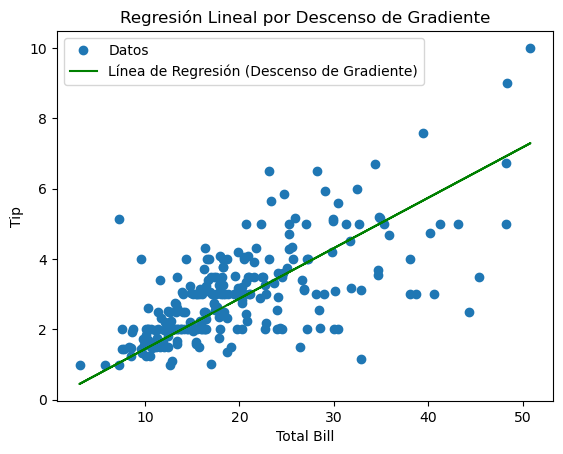

In [14]:
# Visualizar la regresión lineal por descenso de gradiente
plt.plot(x, y, 'o', label='Datos')
plt.plot(x, theta_0 + theta_1 * x, 'g-', label='Línea de Regresión (Descenso de Gradiente)')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Regresión Lineal por Descenso de Gradiente')
plt.legend()
plt.show()

In [15]:
# Predicción de valores con descenso de gradiente
value_user = 50
y_pred_gd = theta_0 + theta_1 * value_user
print(f'El valor predicho de propina para una cuenta total de {value_user} es: {y_pred_gd:.2f}')

El valor predicho de propina para una cuenta total de 50 es: 7.18


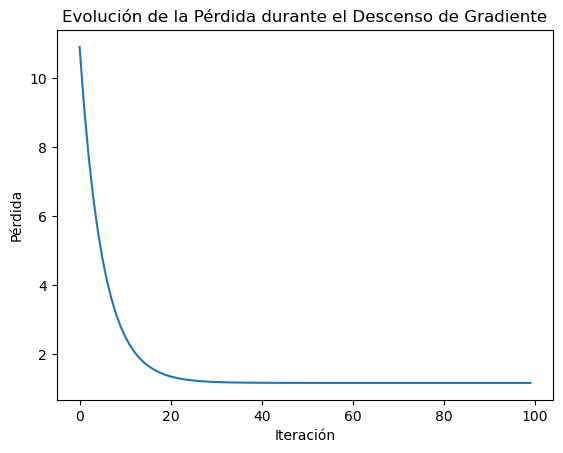

In [16]:
# Visualizar las pérdidas
plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.title('Evolución de la Pérdida durante el Descenso de Gradiente')
plt.show()

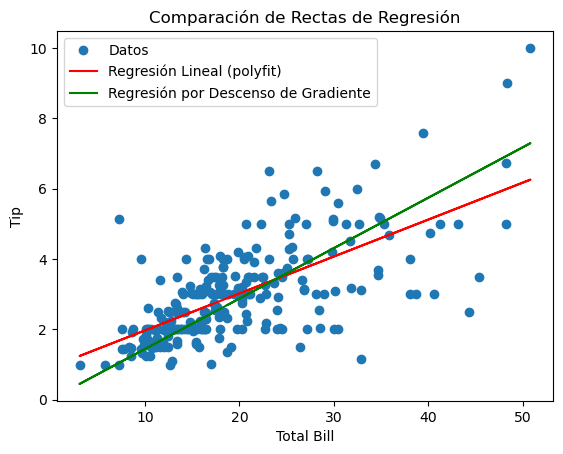

In [17]:
# Comparar las rectas obtenidas por los algoritmos
plt.plot(x, y, 'o', label='Datos')
plt.plot(x, beta * x + alpha, 'r-', label='Regresión Lineal (polyfit)')
plt.plot(x, theta_0 + theta_1 * x, 'g-', label='Regresión por Descenso de Gradiente')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Comparación de Rectas de Regresión')
plt.legend()
plt.show()

## **CHALLENGE: ANÁLISIS PREDICTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística inferencial***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística inferecial** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Prueba de hipótesis**
*   **Aprendizaje estadístico**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [18]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [19]:
# Importar dataset
df_taxis = sns.load_dataset('taxis')
df_taxis = df_taxis.dropna()
df_taxis.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


**3. Realiza una prueba de hipótesis:** Determina si existe una diferencia significativa entre la distancia recorrida de los taxis color amarillo y verde.

Donde:

   * H0: La media de distancia es igual para ambos colores.
   * H1: La media de distancia es distinta entre colores.

In [20]:
# Importar módulo
from scipy import stats

In [21]:
# Separación de grupos
distancia_amarillo = df_taxis[df_taxis['color'] == 'yellow']['distance']
distancia_verde = df_taxis[df_taxis['color'] == 'green']['distance']

In [22]:
# Aplicar Prueba T de Student
t_stat, p_value = stats.ttest_ind(distancia_amarillo, distancia_verde)
print(f'Estadístico t: {t_stat:.4f}')
print(f'Valor p: {p_value:.4f}')

Estadístico t: -3.7744
Valor p: 0.0002


In [23]:
# Interpretación automática
alpha_sig = 0.05
if p_value < alpha_sig:
    print('Conclusión: Rechazamos la hipótesis nula.')
    print('Existe una diferencia significativa en la distancia recorrida entre taxis amarillos y verdes.')
else:
    print('Conclusión: No rechazamos la hipótesis nula.')
    print('No hay suficiente evidencia para afirmar que existe una diferencia significativa en la distancia recorrida entre taxis amarillos y verdes.')

Conclusión: Rechazamos la hipótesis nula.
Existe una diferencia significativa en la distancia recorrida entre taxis amarillos y verdes.


**4. Realiza un aprendizaje estadístico:**

   * Crea un modelo de regresión lineal simple para predecir el costo del viaje en función de la distancia recorrida.
   * Ajusta el modelo a través del algoritmo de optimización del descenso de gradiente.
   * Utiliza el modelo ajustado para realizar una predicción de cuánto costará un viaje de dado un valor agregado por el usuario en unidades de distancia.

In [24]:
# Definir regresión lineal
x = df_taxis['distance']
y = df_taxis['fare']

linea_regresion = np.polyfit(x, y, 1)
beta, alpha = linea_regresion
print(f'y = {beta:.4f}x + {alpha:.4f}')

y = 2.7325x + 4.6967


In [25]:
# Realizar algoritmo del descenso de gradiente
tamaño_paso = 0.001
theta_0 = 0
theta_1 = 0
perdida = []

num_iterations = 1000
for i in range(num_iterations):
    y_pred = theta_0 + theta_1 * x
    error = ((y - y_pred) ** 2).mean()
    perdida.append(error)
    d_theta_0 = (2/len(x)) * (y_pred - y).sum()
    d_theta_1 = (2/len(x)) * ((y_pred - y) * x).sum()

    theta_0 -= tamaño_paso * d_theta_0
    theta_1 -= tamaño_paso * d_theta_1

print(f'Parámetros finales: theta_0 = {theta_0:.4f}, theta_1 = {theta_1:.4f}')

Parámetros finales: theta_0 = 3.4062, theta_1 = 2.9066


In [26]:
# Predicción de valores con descenso de gradiente
value_user = 5
y_pred_gd = theta_0 + theta_1 * value_user
print(f'El costo predicho para un viaje de {value_user} unidades de distancia es: {y_pred_gd:.2f}')

El costo predicho para un viaje de 5 unidades de distancia es: 17.94


**5. Visualiza los resultados:**

   * Grafica las líneas de las regresiones para comparar entre la regresión lineal simple y el algoritmo de optimización.
   * Grafica la función de costo resultante del ajuste con el algoritmo de optimización.

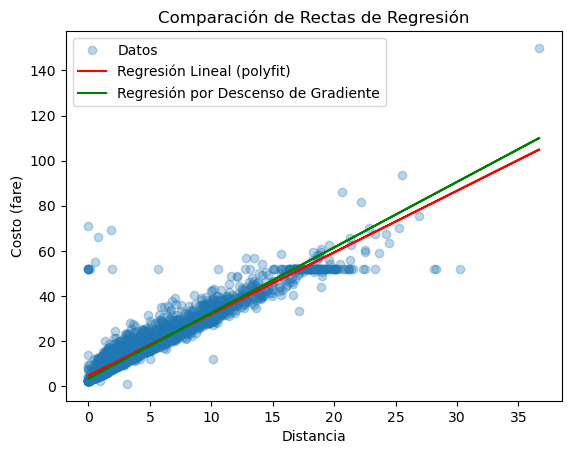

In [27]:
# Visualizar regresiones
plt.plot(x, y, 'o', label='Datos', alpha=0.3)
plt.plot(x, beta * x + alpha, 'r-', label='Regresión Lineal (polyfit)')
plt.plot(x, theta_0 + theta_1 * x, 'g-', label='Regresión por Descenso de Gradiente')
plt.xlabel('Distancia')
plt.ylabel('Costo (fare)')
plt.title('Comparación de Rectas de Regresión')
plt.legend()
plt.show()

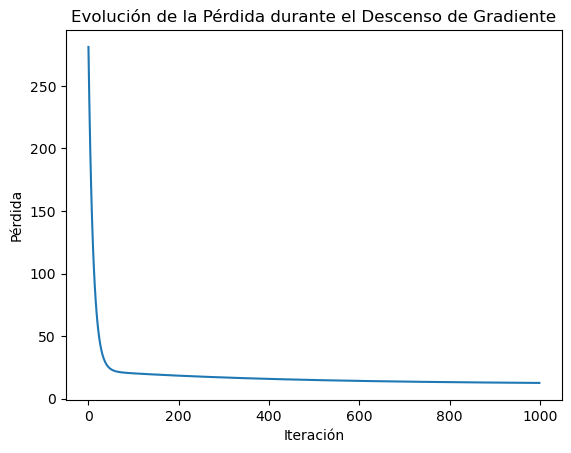

In [28]:
# Visualizar función de costo
plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.title('Evolución de la Pérdida durante el Descenso de Gradiente')
plt.show()